In [1]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

In [2]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

**Data Curation**

In [3]:
print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])

['color', 'grayscale', 'segmented']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


**Number of Classes = 38**

In [4]:
print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])

423
['00e00912-bf75-4cf8-8b7d-ad64b73bea5f___Mt.N.V_HL 6067.JPG', '0163a6aa-fbf8-47c5-965f-59b6efe8bfe5___Mt.N.V_HL 6103.JPG', '0294ca65-4c29-44be-af28-501df9f715e8___Mt.N.V_HL 6176.JPG', '02f95acb-5d92-4f2a-b7ec-3af8709ee7c9___Mt.N.V_HL 9078.JPG', '03027791-26bb-4c46-960e-8df76e27042c___Mt.N.V_HL 6070.JPG']


**Data Preprocessing**

In [5]:
# Dataset Path
base_dir = 'plantvillage dataset/color'

(256, 256, 3)


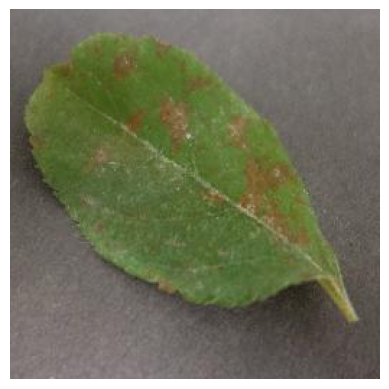

In [6]:
image_path = f'{base_dir}/Apple___Cedar_apple_rust/fc477749-2fe6-48a5-9393-5eedeb7cedc3___FREC_C.Rust 3826.JPG'

# Read the image
img = mpimg.imread(image_path)

print(img.shape)
# Display the image
plt.imshow(img)
plt.axis('off')  # Turn off axis numbers
plt.show()

In [7]:
image_path = f'{base_dir}/Apple___Cedar_apple_rust/fc477749-2fe6-48a5-9393-5eedeb7cedc3___FREC_C.Rust 3826.JPG'

# Read the image
img = mpimg.imread(image_path)

print(img)

[[[119 114 111]
  [120 115 112]
  [121 116 113]
  ...
  [134 129 126]
  [132 127 124]
  [131 126 123]]

 [[120 115 112]
  [120 115 112]
  [121 116 113]
  ...
  [132 127 124]
  [132 127 124]
  [132 127 124]]

 [[121 116 113]
  [121 116 113]
  [122 117 114]
  ...
  [130 125 122]
  [132 127 124]
  [133 128 125]]

 ...

 [[129 119 118]
  [125 115 114]
  [127 117 116]
  ...
  [ 78  68  66]
  [ 78  68  66]
  [ 85  75  73]]

 [[132 122 121]
  [126 116 115]
  [126 116 115]
  ...
  [ 86  76  74]
  [ 83  73  71]
  [ 79  69  67]]

 [[132 122 121]
  [125 115 114]
  [123 113 112]
  ...
  [ 95  85  83]
  [ 90  80  78]
  [ 72  62  60]]]


In [8]:
# Image Parameters
img_size = 224
batch_size = 32

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    subset='training',
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    subset='validation',
    class_mode='categorical',
    shuffle=False
)

Found 43457 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [10]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

In [11]:
# model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │           9,766 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

**Model training**

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 2850s 2s/step - accuracy: 0.8011 - loss: 0.6663 - val_accuracy: 0.9100 - val_loss: 0.2760 - learning_rate: 0.0010
Epoch 2/20
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3640s 3s/step - accuracy: 0.8825 - loss: 0.3615 - val_accuracy: 0.9225 - val_loss: 0.2257 - learning_rate: 0.0010
Epoch 3/20
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 4391s 3s/step - accuracy: 0.8973 - loss: 0.3122 - val_accuracy: 0.9281 - val_loss: 0.2136 - learning_rate: 0.0010
Epoch 4/20
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 1453s 1s/step - accuracy: 0.9028 - loss: 0.2924 - val_accuracy: 0.9349 - val_loss: 0.1930 - learning_rate: 0.0010
Epoch 5/20
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 1442s 1s/step - accuracy: 0.9072 - loss: 0.2789 - val_accuracy: 0.9299 - val_loss: 0.2128 - learning_rate: 0.0010
Epoch 6/20
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 1408s 1s/step - accuracy: 0.9124 - loss: 0.2654 - val_accuracy: 0.9358 - val_loss: 0.1939 - learning_rate: 0.0010
Epoch 7/20
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 13990s 10s/step - accu

**Model Evaluation**

In [14]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 89s 262ms/step - accuracy: 0.9511 - loss: 0.1426
Validation Accuracy: 95.11%


In [15]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 955s 695ms/step - accuracy: 0.8485 - loss: 0.5363 - val_accuracy: 0.9404 - val_loss: 0.1762 - learning_rate: 1.0000e-05
Epoch 2/10
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 912s 671ms/step - accuracy: 0.9134 - loss: 0.2624 - val_accuracy: 0.9430 - val_loss: 0.1652 - learning_rate: 1.0000e-05
Epoch 3/10
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 936s 689ms/step - accuracy: 0.9249 - loss: 0.2224 - val_accuracy: 0.9469 - val_loss: 0.1550 - learning_rate: 2.0000e-06
Epoch 4/10
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 985s 725ms/step - accuracy: 0.9321 - loss: 0.2090 - val_accuracy: 0.9491 - val_loss: 0.1488 - learning_rate: 2.0000e-06


In [16]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 98s 289ms/step - accuracy: 0.9404 - loss: 0.1762
Validation Accuracy: 94.04%


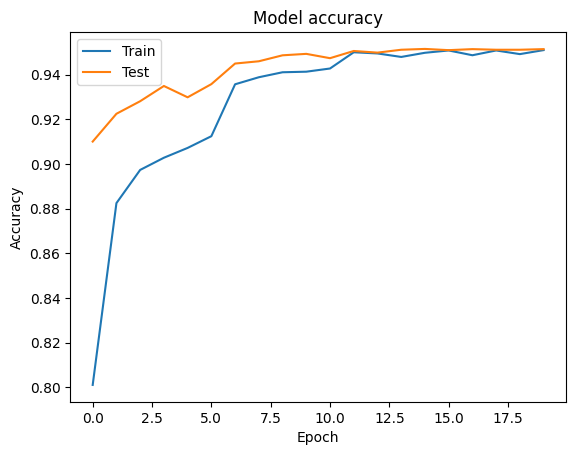

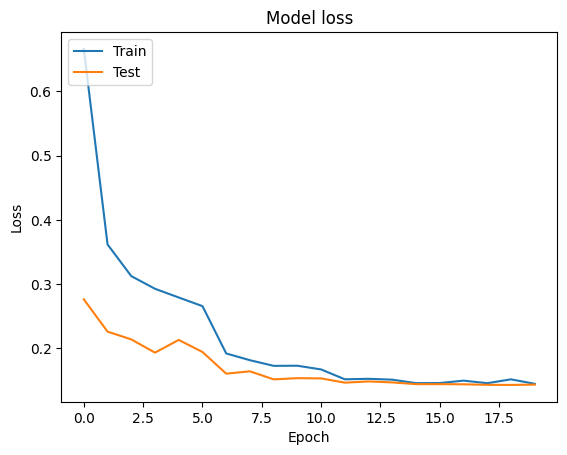

In [17]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

**Building a Predictive System**

In [18]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [19]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [20]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [21]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [22]:
# Example Usage
image_path = f'../test_images/test_apple_black_rot.JPG'
#image_path = '/content/test_blueberry_healthy.jpg'
#image_path = '/content/test_potato_early_blight.jpg'
predicted_class_name = predict_image_class(model, image_path, class_indices)

# Output the result
print("Predicted Class Name:", predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class Name: Tomato___Septoria_leaf_spot


In [23]:
from sklearn.metrics import classification_report
import numpy as np

# Make sure validation order is fixed
validation_generator.reset()

# Get predictions
pred_probs = model.predict(validation_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = validation_generator.classes

# Calculate metrics
report = classification_report(
    y_true,
    y_pred,
    target_names=list(validation_generator.class_indices.keys()),
    output_dict=True,
    zero_division=0
)

print(f"Accuracy: {report['accuracy'] * 100:.2f}%")
print(f"Macro Precision: {report['macro avg']['precision'] * 100:.2f}%")
print(f"Macro Recall: {report['macro avg']['recall'] * 100:.2f}%")
print(f"Macro F1: {report['macro avg']['f1-score'] * 100:.2f}%")

340/340 ━━━━━━━━━━━━━━━━━━━━ 92s 265ms/step
Accuracy: 94.04%
Macro Precision: 92.67%
Macro Recall: 92.01%
Macro F1: 92.07%


In [25]:
model.save('plant_disease_prediction_model.keras')